In [1]:
# Let's add the root directory to our system search path to allow imports from sibling directories.
import os, sys
module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

In [20]:
import gc, random
from pathlib import Path

import torch
import numpy as np

import matplotlib.pyplot as plt

# Import your modules
from src.dino import ConvNeXtV2, DINOHead
from src.dataset import SonarDataset
from src.utils import load_backbone, run_inference, load_model, run_inference_heads

WEIGHTS_DIR = Path("../weights/")
EPOCH_COUNT = len(list(WEIGHTS_DIR.iterdir())) - 2

DEVICE = torch.device("cuda")  # ConvNeXtV2 doesn't support CPU

NUM_SAMPLES = 100  # For ablation tests
DATASET = SonarDataset(data_dir="../data/processed/")
N = len(DATASET)

In [26]:
def get_outputs(model: ConvNeXtV2, dino_head: DINOHead, ibot_head: DINOHead):
    patches = [DATASET[i * N // NUM_SAMPLES][0] for i in range(NUM_SAMPLES)]

    embeds, dino, ibot = [], [], []
    for p in patches:
        dino_out, ibot_out, outputs = run_inference_heads(model, dino_head, ibot_head, p)

        embeds.append(outputs[-1])  # Add hypercolumn output
        dino.append(dino_out)
        ibot.append(ibot_out)

    return embeds, dino, ibot


def compute_feature_svd(embeddings_list):
    """
    Computes the Singular Value Decomposition (SVD) on the covariance matrix 
    of patch embeddings to analyze dimensional collapse.

    Source: https://arxiv.org/abs/2110.09348

    Args:
        embeddings_list (list of np.ndarray): A list of embedding arrays, 
                                              each of shape (w, h, c).

    Returns:
        np.ndarray: The singular values of the covariance matrix.
    """
    flattened_embeddings = [emb.reshape(-1, emb.shape[-1]) for emb in embeddings_list]

    # Mean center embeddings
    Z = np.vstack(flattened_embeddings)
    Z_centered = Z - np.mean(Z, axis=0)

    # Compute the covariance matrix C of size (c, c)
    N = Z_centered.shape[0]
    C = (Z_centered.T @ Z_centered) / N

    # Perform SVD on the covariance matrix C
    # C = U * S * V^T
    U, S, Vh = np.linalg.svd(C)

    return S


def compute_effective_rank(singular_values, eps=1e-12):
    """
    Computes the effective rank of a matrix based on its singular values.
    
    The effective rank is calculated using the Shannon entropy of the 
    normalized singular values. A higher effective rank indicates that 
    the variance is more evenly distributed across dimensions, meaning 
    less dimensional collapse.

    Args:
        singular_values (np.ndarray): A 1D numpy array of singular values.

    Returns:
        float: The effective rank.
    """
    sv_clean = singular_values[singular_values > eps]

    # Normalize the singular values to create a probability distribution
    l1_norm = np.sum(sv_clean)
    if l1_norm == 0:
        return 0.0

    p = sv_clean / l1_norm

    # Calculate Shannon entropy: H = -sum(p * ln(p))
    entropy = -np.sum(p * np.log(p))

    # Calculate effective rank: exp(H)
    return np.exp(entropy)


def plot_feature_svd(singular_values, epoch, eps=1e-6):
    """
    Plots the log of singular values against the singular value rank index.
    
    Args:
        singular_values (np.ndarray): The singular values obtained from SVD.
    """
    log_singular_values = np.log(singular_values + eps)

    plt.figure(figsize=(8, 6))
    plt.plot(log_singular_values, color='steelblue')

    plt.title(f'Singular Value Spectrum of the Embedding Space (EPOCH {epoch})')
    plt.xlabel('Singular Value Rank Index')
    plt.ylabel('Log of singular values')

    # Set y-axis limits to clearly show the drop-off of collapsed dimensions
    plt.ylim([np.min(log_singular_values) - 2, np.max(log_singular_values) + 2])

    plt.tight_layout()
    plt.show()

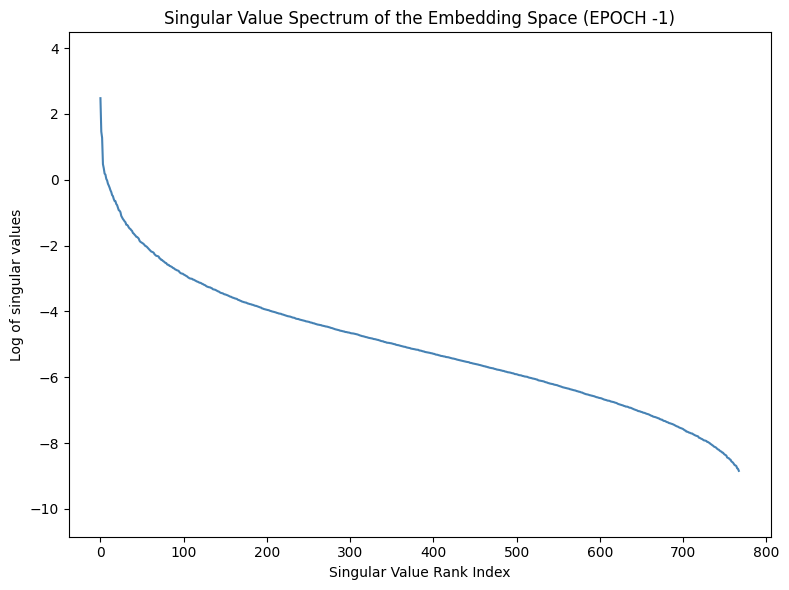

Effective Rank: 59.40940012513962



In [27]:
model = load_backbone(WEIGHTS_DIR / "pretrained.pth")
embeds = [run_inference(model, DATASET[i * N // NUM_SAMPLES][0])[-1][-1] for i in range(NUM_SAMPLES)]

singular_vals = compute_feature_svd(embeds)
rank = compute_effective_rank(singular_vals)

plot_feature_svd(singular_vals, -1)

print(f"Effective Rank: {rank}\n")

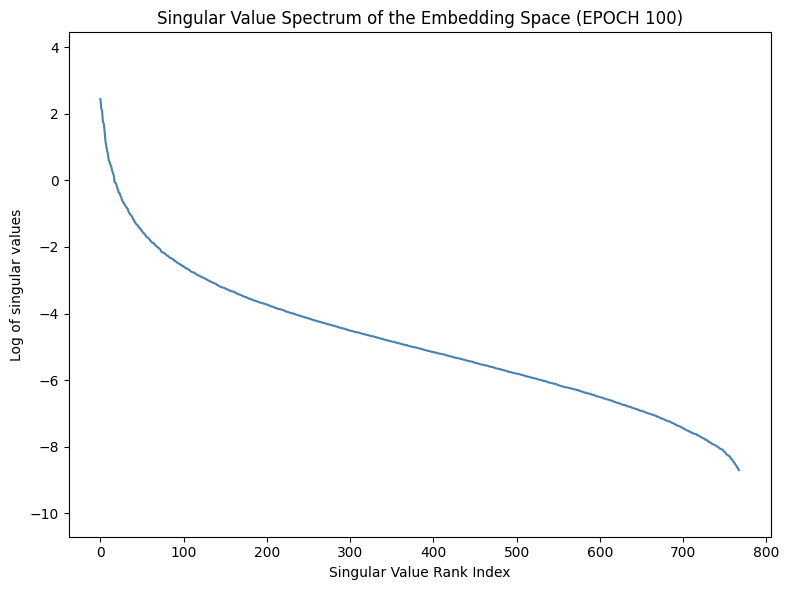

Effective Rank: 53.806756388345384



In [28]:
model, dino, ibot = load_model(WEIGHTS_DIR / "checkpoint_latest.pth")
embeds, dino_out, ibot_out = get_outputs(model, dino, ibot)

singular_vals = compute_feature_svd(embeds)
rank = compute_effective_rank(singular_vals)

plot_feature_svd(singular_vals, EPOCH_COUNT - 1)

print(f"Effective Rank: {rank}\n")


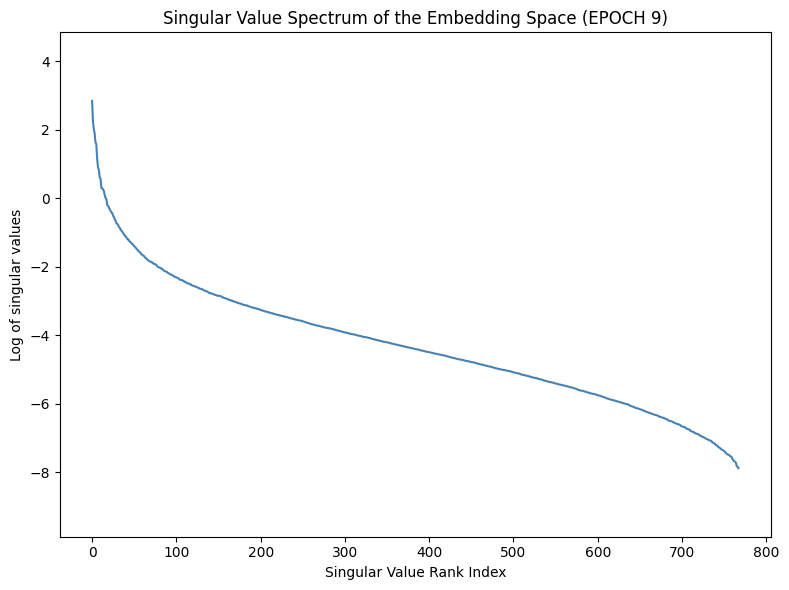

Effective Rank: 59.70168742312563



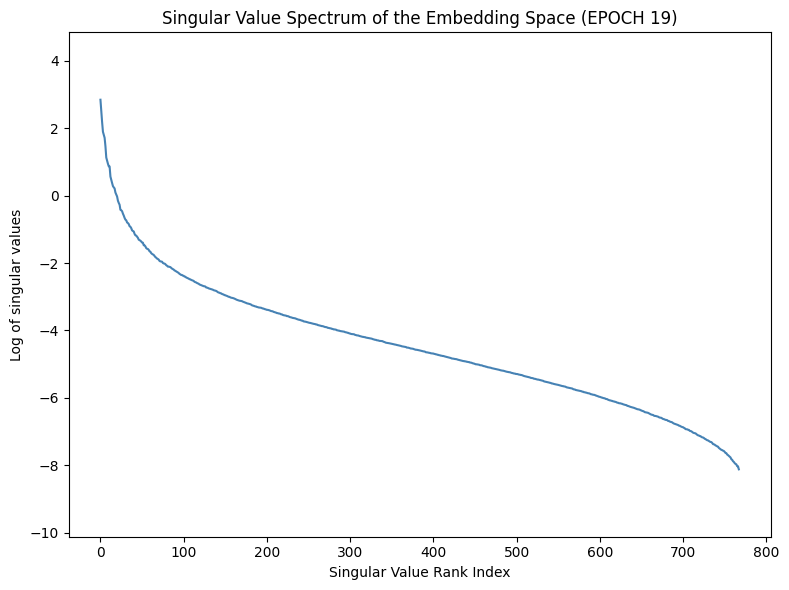

Effective Rank: 52.356979079776366



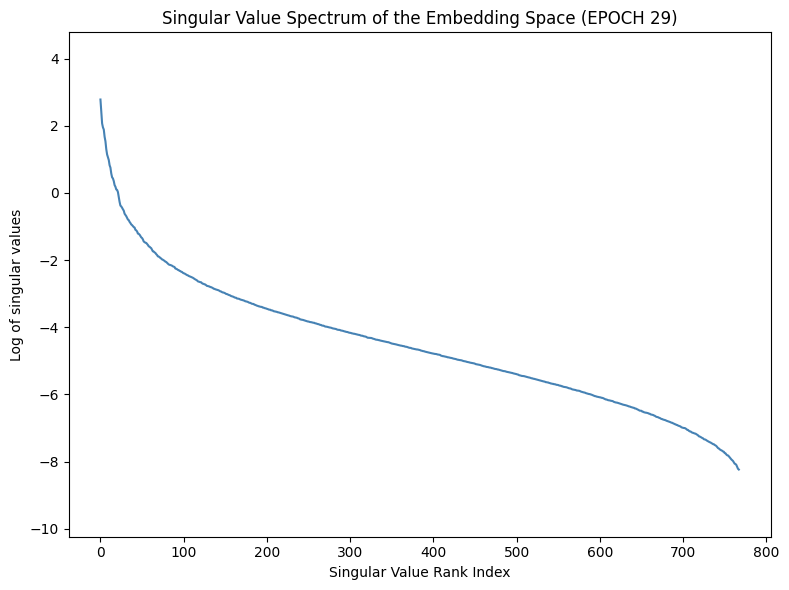

Effective Rank: 53.669436216190945



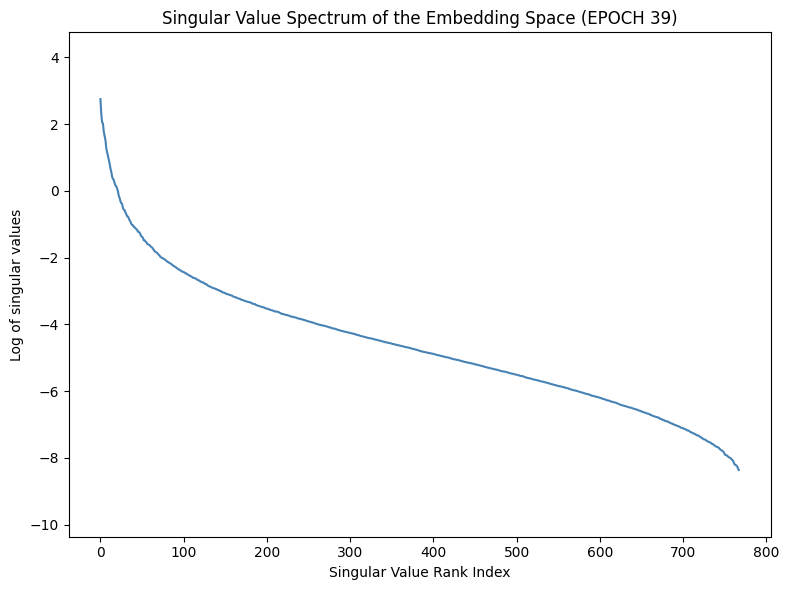

Effective Rank: 53.210193422656005



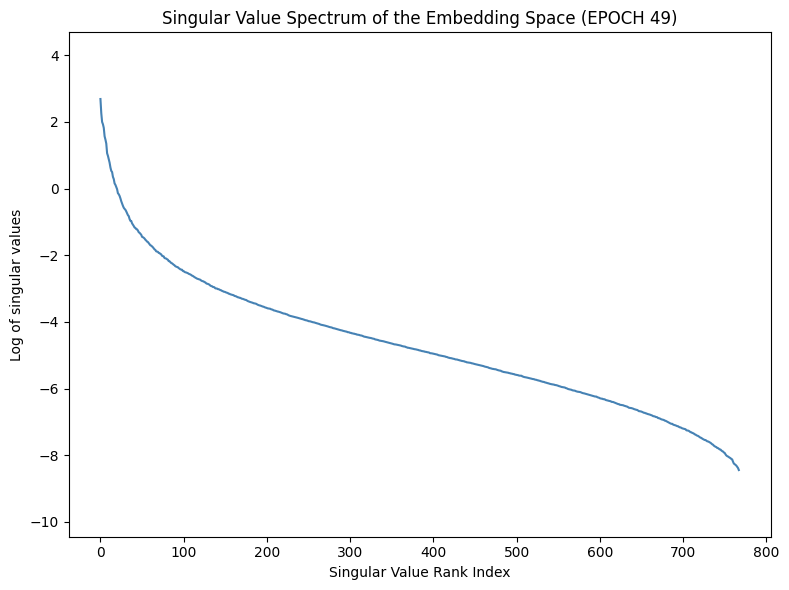

Effective Rank: 53.58008916236272



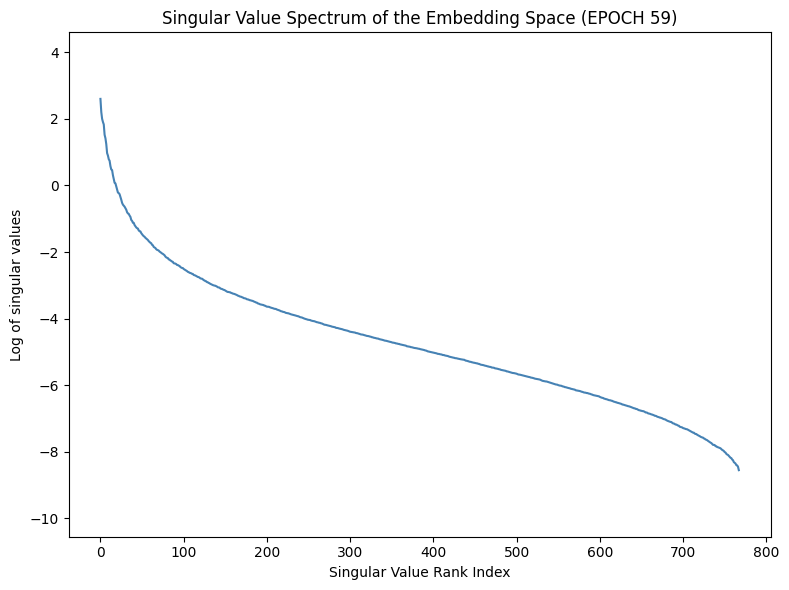

Effective Rank: 53.630835976076725



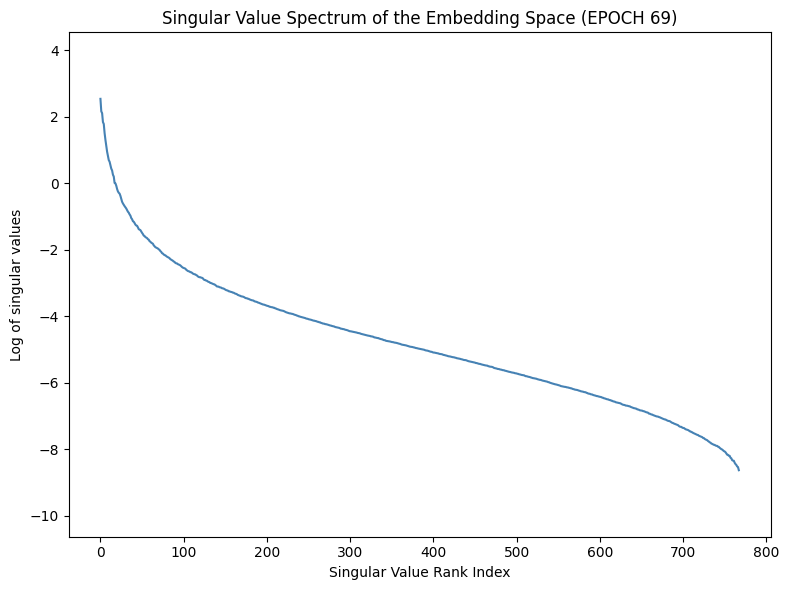

Effective Rank: 53.34619413282081



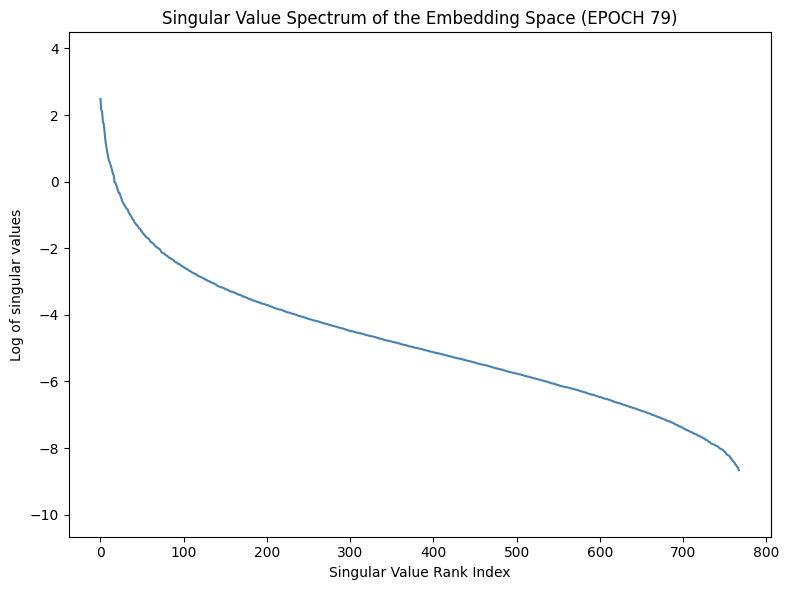

Effective Rank: 53.737081076155974



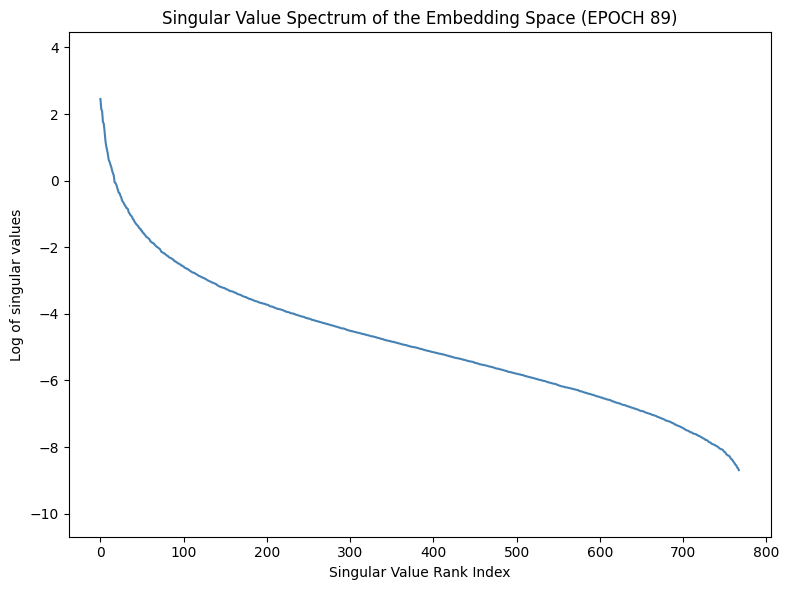

Effective Rank: 53.73477230033719



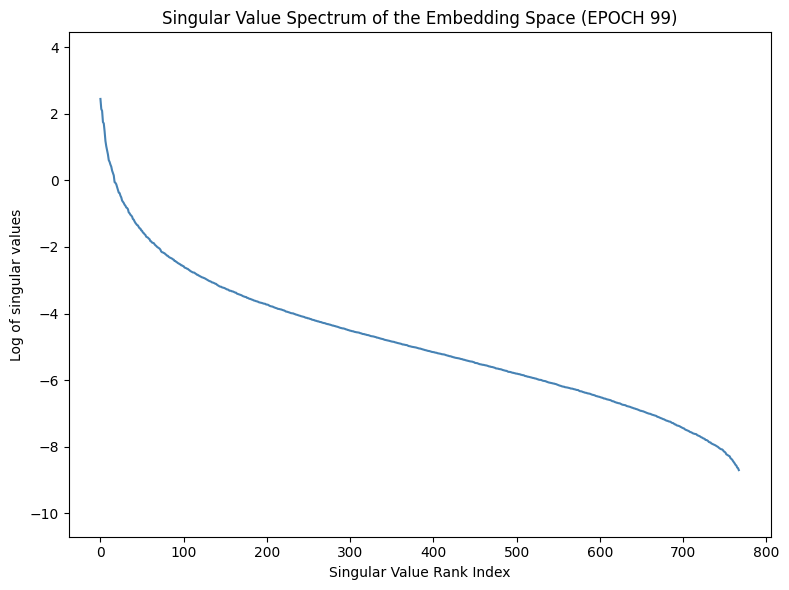

Effective Rank: 53.80675209246244



In [29]:
for epoch in range(9, EPOCH_COUNT - 1, 10):
    model, dino, ibot = load_model(WEIGHTS_DIR / f"checkpoint_{epoch}.pth")
    embeds, dino_out, ibot_out = get_outputs(model, dino, ibot)

    singular_vals = compute_feature_svd(embeds)
    rank = compute_effective_rank(singular_vals)

    plot_feature_svd(singular_vals, epoch)

    print(f"Effective Rank: {rank}\n")

    del model, dino, ibot
    del embeds, dino_out, ibot_out, singular_vals
    torch.cuda.empty_cache()
    gc.collect()